In [1]:
# Model Development for Flight Delay Prediction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set up visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set(font_scale=1.2)
%matplotlib inline

print("Setup complete.")

# Load the enriched dataset with weather features
data_path = '../data/flights_weather_features.csv'
df = pd.read_csv(data_path, parse_dates=['FL_DATE'])

# Display basic information about the dataset
print(f"Dataset loaded with shape: {df.shape}")
print(f"Features available: {df.columns.tolist()}")

# Check for missing values, especially in weather features
missing_counts = df.isnull().sum()
print("\nMissing values per column:")
print(missing_counts[missing_counts > 0])

Setup complete.
Dataset loaded with shape: (2913802, 19)
Features available: ['FL_DATE', 'AIRLINE', 'ORIGIN', 'DEST', 'DISTANCE', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'IS_DELAYED', 'ORIGIN_TEMP_MAX', 'ORIGIN_TEMP_MIN', 'ORIGIN_PRECIPITATION', 'ORIGIN_RAIN', 'ORIGIN_SNOW', 'DEST_TEMP_MAX', 'DEST_TEMP_MIN', 'DEST_PRECIPITATION', 'DEST_RAIN', 'DEST_SNOW']

Missing values per column:
ORIGIN_TEMP_MAX         2866070
ORIGIN_TEMP_MIN         2866070
ORIGIN_PRECIPITATION    2866070
ORIGIN_RAIN             2866070
ORIGIN_SNOW             2866070
DEST_TEMP_MAX           2865966
DEST_TEMP_MIN           2865966
DEST_PRECIPITATION      2865966
DEST_RAIN               2865966
DEST_SNOW               2865966
dtype: int64



Class distribution for delay prediction:
IS_DELAYED
0    82.315579
1    17.684421
Name: proportion, dtype: float64

Working with 19136 rows that have complete weather data

Correlations between weather features and delays:
IS_DELAYED              1.000000
DEST_PRECIPITATION      0.075504
DEST_RAIN               0.073554
ORIGIN_SNOW             0.066078
ORIGIN_PRECIPITATION    0.064584
ORIGIN_RAIN             0.058402
ORIGIN_TEMP_MIN         0.044317
DEST_TEMP_MIN           0.043262
ORIGIN_TEMP_MAX         0.028654
DEST_TEMP_MAX           0.028257
DEST_SNOW               0.022329
Name: IS_DELAYED, dtype: float64


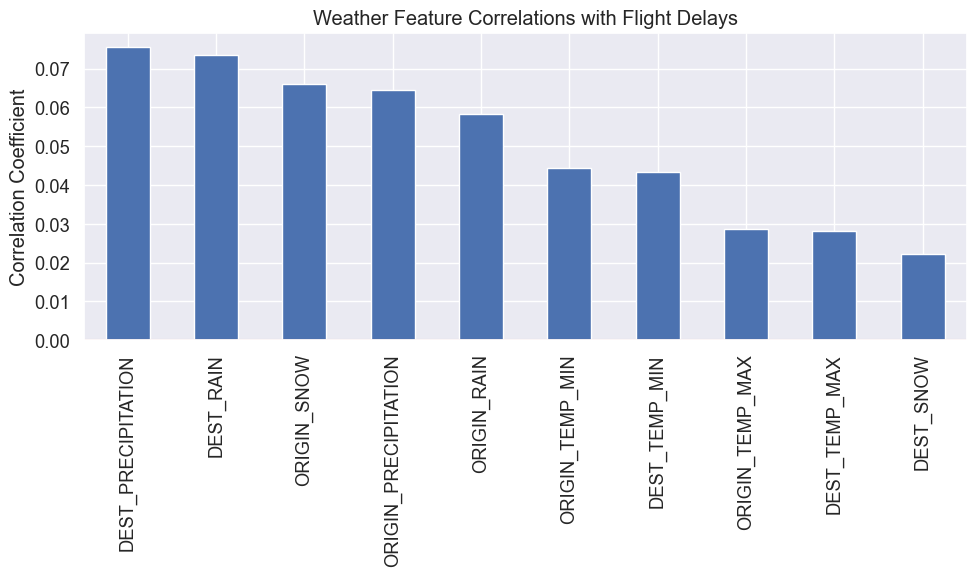

In [2]:
# Examine class balance for the target variable
print("\nClass distribution for delay prediction:")
print(df['IS_DELAYED'].value_counts(normalize=True) * 100)

# Explore correlations between weather features and delays
weather_cols = [col for col in df.columns if any(x in col for x in ['TEMP', 'PRECIPITATION', 'RAIN', 'SNOW'])]
delay_weather_df = pd.DataFrame()
delay_weather_df['IS_DELAYED'] = df['IS_DELAYED']
for col in weather_cols:
    delay_weather_df[col] = df[col]

# Calculate correlation with target (only for rows with weather data)
delay_weather_complete = delay_weather_df.dropna()
print(f"\nWorking with {len(delay_weather_complete)} rows that have complete weather data")

# Correlation analysis
correlations = delay_weather_complete.corr()['IS_DELAYED'].sort_values(ascending=False)
print("\nCorrelations between weather features and delays:")
print(correlations)

# Visualize the correlations
plt.figure(figsize=(10, 6))
correlations.drop('IS_DELAYED').plot(kind='bar')
plt.title('Weather Feature Correlations with Flight Delays')
plt.ylabel('Correlation Coefficient')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
# Strategy for handling missing weather data
print(f"Missing origin weather: {df['ORIGIN_TEMP_MAX'].isna().sum()} out of {len(df)} rows ({df['ORIGIN_TEMP_MAX'].isna().mean()*100:.2f}%)")
print(f"Missing destination weather: {df['DEST_TEMP_MAX'].isna().sum()} out of {len(df)} rows ({df['DEST_TEMP_MAX'].isna().mean()*100:.2f}%)")

# Options:
# 1. Filter to include only flights with weather data
complete_weather_df = df.dropna(subset=['ORIGIN_TEMP_MAX', 'DEST_TEMP_MAX'])
print(f"\nComplete weather data available for {len(complete_weather_df)} flights ({len(complete_weather_df)/len(df)*100:.2f}% of dataset)")

# 2. Use mean imputation for missing weather values
# 3. Create binary flags for missing weather data
# Let's implement option 2 and 3 together

# Create missing weather indicator features
df['MISSING_ORIGIN_WEATHER'] = df['ORIGIN_TEMP_MAX'].isna().astype(int)
df['MISSING_DEST_WEATHER'] = df['DEST_TEMP_MAX'].isna().astype(int)

print("\nPrepared dataset for modeling with missing weather indicators")

Missing origin weather: 2866070 out of 2913802 rows (98.36%)
Missing destination weather: 2865966 out of 2913802 rows (98.36%)

Complete weather data available for 19136 flights (0.66% of dataset)

Prepared dataset for modeling with missing weather indicators
